# 🧠🤖 Treinamento de Redes LSTM para Classificação

- **Deadline**: 18/02/2026
- **Entrega**: O trabalho deve ser entregue via sistema Testr.
- **Pontuação**: 20% da nota do semestre
- O trabalho deve ser realizado individualmente.



## Especificação


### Contexto

O trabalho consiste em realizar o treinamento de redes LSTM usando a base de dados [BBC News Archive disponível no kaggle](https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive?select=bbc-news-data.csv). Esta base de dados contém 2.225 textos publicados no site de notícias da BBC news entre 2004-2005. Cada notícia foi classificada como sendo de um dos seguintes assuntos: business (negócios), entertainment (entretenimento), politics (política), sport (esportes), tech (tecnologia).

O objetivo do trabalho é treinar uma rede neural capaz de identificar o tema de um texto.


### Implementação

- Use o notebook de classificação de sentimentos como ponto de partida.
- use a biblioteca `kagglehub` para fazer o download do dataset no colab.
- Um dos modelos de *word embeddings* disponíveis na biblioteca `gensim` deve ser utilizado para mapear palavras em vetores.
- Use o tipo `nn.LSTM` disponível no `pytorch` (não é necessário implementar a camada LSTM do zero).
- Os dados devem ser divididos em treino, validação e teste. Use o conjunto de validação para ajustar hiperparâmetros e para selecionar o modelo com melhor generalização. Avalie o modelo resultante usando o conjunto de teste apenas ao final.
- Você pode optar por cortar os textos em um tamanho máximo (e.g., 100 palavras), como fizemos no notebook, para que os testes não demorem muito.
- Use o ambiente de `GPU` do colab para evitar que o treinamento demore excessivamente.
- Durante o desenvolvimento, é uma boa idéia usar um subconjunto (e.g., 10%) das notícias para que os testes sejam mais rápidos. Quando tudo estiver correto, faça o treinamento com a base completa.
- Deve ser plotado o gráfico mostrando a evolução da função de perda nos conjuntos de treino e validação.
- Devem ser mostradas as métricas geradas pela função `classification_report` da biblioteca scikit-learn e a matriz de confusão para o conjunto de teste.
- Faça alguns testes qualitativos com textos escritos com você (não use textos da base de dados).
- Discuta brevemente os resultados quantitativos e qualitativos (1-2 parágrafos, no máximo).


[texto do link](https://)
### Pontos Extras

Receberá um ponto extra, o aluno que:
- Utilizar um LLM baseado em Transformer pré-treinado (e.g., [BERT](https://medium.com/@davidlfliang/intro-getting-started-with-text-embeddings-using-bert-9f8c3b98dee6)) para mapear as notícias em *embeddings*.
- Utilizar uma rede Multilayer Perceptron para classificar os *embeddings*.
- Comparar a performance desta solução com a LSTM.

⚠️**IMPORTANTE**⚠️
- Não é necessário (nem recomendável considerando o prazo) tentar realizar *fine-tuning* do LLM pré-treinado.
- Estes modelos são SUPER-ULTRA-MASTER-BLASTER lentos na CPU. Use o ambiente de GPU do colab para evitar ficar 20h esperando para transformar os textos em *embeddings*.
- Salve os embeddings depois da geração para evitar ter que gerá-los novamente. Quando necessário, faça upload do arquivo novamente para o colab.

## Implementação

### Imports e Downloads

In [ ]:
!git clone https://github.com/paaatcha/raug.git
!pip install -q tensorboardX python-telegram-bot
!python -m pip install gensim

# ------------------------------------------------------------------------------

import os
import gensim.downloader
import torch
import time
import kagglehub

import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F


from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split, KFold
from collections import Counter
from torch.utils.data import Subset
from raug.raug.train import fit_model
from raug.raug.eval import test_model
from google.colab import drive

Cloning into 'raug'...
remote: Enumerating objects: 922, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 922 (delta 88), reused 98 (delta 51), pack-reused 779 (from 1)
Receiving objects: 100% (922/922), 229.47 KiB | 1.93 MiB/s, done.
Resolving deltas: 100% (567/567), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.3/737.3 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.2 MB/s eta 0:00:00


/content/raug/raug/train.py:353: SyntaxWarning: invalid escape sequence '\-'
  new_best_print = '\-- New best {}: {:.3f}'.format(best_metric, best_metric_value)


In [ ]:
path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bbcnewsarchive' dataset.
Path to dataset files: /kaggle/input/bbcnewsarchive


In [ ]:
list(gensim.downloader.info()['models'].keys())

embedding_model = gensim.downloader.load('glove-twitter-50')

[==================================================] 100.0% 199.5/199.5MB downloaded


### Pré Processamento de Dados

In [ ]:
embedding = embedding_model['news']
embedding

array([ 1.242   ,  0.12836 , -0.067961, -0.81323 , -0.09191 ,  0.052386,
       -0.020837, -0.041742,  0.76237 , -0.73536 ,  0.15401 , -0.84617 ,
       -3.6415  ,  0.49982 ,  0.13838 , -0.61487 , -0.45004 ,  0.76693 ,
        0.99637 , -0.19401 , -0.40866 , -0.67173 , -0.3662  , -0.93978 ,
       -0.28966 ,  0.64456 , -0.044505,  0.4138  , -0.037879,  0.31929 ,
       -0.55858 , -0.8237  , -0.59801 ,  0.54597 ,  1.3586  ,  0.38548 ,
        0.18049 , -0.085998,  0.40831 , -1.1277  , -1.9454  , -0.047869,
       -0.11589 ,  1.2125  , -0.060388,  0.29345 , -0.35128 , -0.60623 ,
       -0.92085 ,  0.27155 ], dtype=float32)

In [ ]:
embedding_model.most_similar('news')

[('bbc', 0.8470500111579895),
 ('uk', 0.8142005801200867),
 ('report', 0.8096610903739929),
 ('latest', 0.8068849444389343),
 ('yahoo', 0.8038555383682251),
 ('via', 0.8024342656135559),
 ('reuters', 0.7930371761322021),
 ('press', 0.7737456560134888),
 ('tech', 0.7729286551475525),
 ('’s', 0.7691500186920166)]

In [ ]:
df = pd.read_csv(path + "/bbc-news-data.csv", sep='\t')
df = df.sample(frac=1, random_state=66).reset_index(drop=True)
df

,category,filename,title,content
0,tech,300.txt,Apple Mac mini gets warm welcome,"The Mac mini has been welcomed by Apple fans,..."
1,sport,048.txt,Greek pair set for hearing,Kostas Kenteris and Katerina Thanou will figh...
2,politics,043.txt,Parties warned over 'grey vote',Political parties cannot afford to take older...
3,politics,412.txt,'Last chance' warning for voters,"People in England, Scotland and Wales must ha..."
4,business,106.txt,Golden rule 'intact' says ex-aide,Chancellor Gordon Brown will meet his golden ...
...,...,...,...,...
2220,politics,251.txt,Brown and Blair face new rift claims,"For the umpteenth time, Tony Blair and Gordon..."
2221,business,052.txt,Italy to get economic action plan,Italian Prime Minister Silvio Berlusconi will...
2222,entertainment,122.txt,Dance music not dead says Fatboy,DJ Norman Cook - aka Fatboy Slim - has said t...
2223,entertainment,319.txt,Music mogul Fuller sells company,Pop Idol supremo Simon Fuller has sold his 19...


In [ ]:
df['category'].unique()

array(['tech', 'sport', 'politics', 'business', 'entertainment'],
      dtype=object)

In [ ]:
df['category'].value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


In [ ]:
import re
import torch
import numpy as np
from textwrap import fill


max_seq_length = 100

def preprocessing(text):
    # remove tags html
    text = re.sub(r"<.*?>", "", text)
    # remove valores não alfanuméricos
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text)
    # converte para minusculo
    text = text.lower()
    # separa palavras
    words = text.split()
    # trunca a sequencia em um tamanho máximo
    # words = words[:max_seq_length]
    # converte as palavras em word embeddings descartando
    # aquelas que não existem e converte o resultado em um torch.tensor
    embds = torch.tensor(np.array([embedding_model[w] for w in words if w in embedding_model]))
    return embds


text = df['content'].iloc[10]
embds = preprocessing(text)

print("text:\n", fill(text))
print("\nembds.shape:", embds.shape)

text:
  Hearts wrapped up their Scottish Cup quarter-final tie against
Livingston with two goals in the first 10 minutes.  Lee Miller scored
inside the opening 60 seconds, heading over Colin Meldrum and into the
net from a Jamie McAllister free kick. McAllister himself scored the
second when he met Saul Mikoliunas' cross at the back post to put the
game beyond the visitors. Craig Easton headed in a controversial goal
after an hour but Hearts held on. The opening goal came after Gus
Bahoken had clumsily fouled Miller 35 yards from goal. McAllister
floated the free kick into the Livi box and Miller outjumped the
static visiting defence to loop his header from 10 yards over Meldrum.
With just 10 minutes on the clock, the home side doubled their lead.
Mikoliunas sprinted down the right, crossed to the back post where
McAllister raced in to head past Meldrum. Moments later Miller came
close to grabbing his second with a first-time drive from 16 yards,
which skimmed the bar.  Then McAllister

In [ ]:
x = [preprocessing(t) for t in df['content']]

print("Num de amostras:", len(x))
print("Tamanho de uma amostra:", x[-9].shape)

Num de amostras: 2225
Tamanho de uma amostra: torch.Size([304, 50])


In [ ]:
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(df['category'].to_numpy())
y = y.astype(np.int64)
y = torch.tensor(y)
y

tensor([4, 3, 2,  ..., 1, 1, 2])

In [ ]:
from torch.nn.utils.rnn import pad_sequence

x_padded = pad_sequence(x, batch_first=True)
x_padded.shape

torch.Size([2225, 4452, 50])

In [ ]:
x_padded[-9]

tensor([[ 0.2532, -0.0149,  0.5937,  ..., -0.2893,  0.4549,  0.1866],
        [ 0.3002, -0.0457,  0.2803,  ...,  0.5728,  0.0348, -0.3223],
        [ 0.4656,  0.3798, -0.2731,  ..., -0.3271, -0.0226, -0.9042],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

#########################################
# Descomente para realizar subamostragem
# sub_x = x_padded[:5000]
# sub_y = y[:5000]
#
# Descomente para executar com o dataset completo.
sub_x = x_padded
sub_y = y
#########################################

aux_x_train, x_test, aux_y_train, y_test = train_test_split(
    sub_x, sub_y,
    test_size=0.2,
    random_state=42,
)

x_train, x_val, y_train, y_val = train_test_split(
    aux_x_train, aux_y_train,
    test_size=0.2,
    random_state=42,
)

train_ds = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

val_ds = TensorDataset(x_val, y_val)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=True)

test_ds = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_ds, batch_size=64)

print("train size:", len(train_ds), "test size:", len(test_ds))

train size: 1424 test size: 445


### LSTM

#### Implementação do Modelo

In [ ]:
from torch import nn

class Model(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        hidden_size = 128

        self.lstm = nn.LSTM(
            input_size=50,
            num_layers=2,
            dropout=0.3,
            hidden_size=hidden_size,
            bidirectional=False,
            batch_first=True,
        )

        self.dropout = nn.Dropout(p=0.3)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, sequence):

        outputs, _ = self.lstm(sequence)
        pooled = outputs.mean(dim=1)
        x = self.dropout(pooled)
        prediction = self.fc(x)

        return prediction

#### Treino

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

num_classes = len(encoder.classes_)
net = Model(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=3e-3)

history = []
n_epochs = 100

patience = 10
best_val_loss = float('inf')
epochs_without_improvement = 0

# repete por um número de épocas
for epoch in range(n_epochs):
    running_loss = 0.0

    # epoca de treinamento: itera sobre os batches do conjunto de treino
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # running_loss /= len(train_ds)
    running_loss /= len(train_loader)

    # avaliação no conjunto de validação
    net.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    # val_loss /= len(val_ds)
    val_loss /= len(val_loader)

    history.append([running_loss, val_loss])

    if epoch % max(1, n_epochs // 100)  == 0:
        print(f'Época: [{epoch + 1}/{n_epochs}] | loss: {running_loss:.4f} | val loss: {val_loss:.4f}')
        # print(f'Época: [{epoch + 1}/{n_epochs}] | loss: {running_loss:.4f} | val loss: {val_loss:.4f} | sem melhora: {epochs_without_improvement}/{patience}')

    # # ---- EARLY STOPPING ----
    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     epochs_without_improvement = 0
    #     best_model_state = net.state_dict()  # opcional: salvar melhor modelo
    # else:
    #     epochs_without_improvement += 1

    # if epochs_without_improvement >= patience:
    #     print(f'\nEarly stopping acionado na época {epoch + 1}')
    #     net.load_state_dict(best_model_state)  # opcional: restaurar melhor modelo
    #     break

print('Finished Training')

Usando: cuda
Época: [1/100] | loss: 1.5866 | val loss: 1.5037
Época: [2/100] | loss: 1.5879 | val loss: 1.4852
Época: [3/100] | loss: 1.4603 | val loss: 1.2614
Época: [4/100] | loss: 1.3597 | val loss: 1.6351
Época: [5/100] | loss: 1.4588 | val loss: 1.3637
Época: [6/100] | loss: 1.4207 | val loss: 1.3910
Época: [7/100] | loss: 1.3849 | val loss: 1.3442
Época: [8/100] | loss: 1.3829 | val loss: 1.3805
Época: [9/100] | loss: 1.3902 | val loss: 1.3437
Época: [10/100] | loss: 1.3871 | val loss: 1.4057
Época: [11/100] | loss: 1.4192 | val loss: 1.3788
Época: [12/100] | loss: 1.4011 | val loss: 1.3574
Época: [13/100] | loss: 1.3697 | val loss: 1.3123
Época: [14/100] | loss: 1.3122 | val loss: 1.2166
Época: [15/100] | loss: 1.1174 | val loss: 0.9639
Época: [16/100] | loss: 1.0299 | val loss: 1.0117
Época: [17/100] | loss: 0.9451 | val loss: 0.9330
Época: [18/100] | loss: 1.0841 | val loss: 0.9694
Época: [19/100] | loss: 1.1034 | val loss: 1.2672
Época: [20/100] | loss: 0.9442 | val loss: 0.7

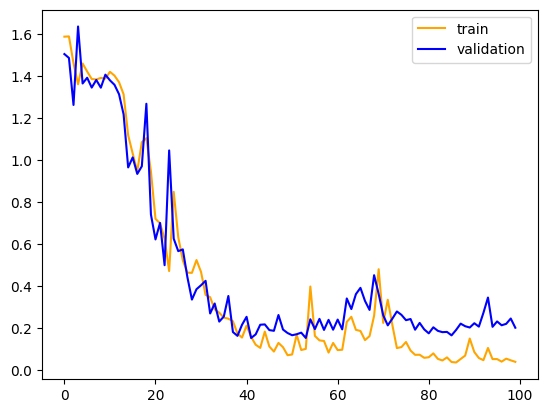

In [ ]:
import matplotlib.pyplot as plt

history = np.array(history)

plt.plot(history[:, 0], '-', color='orange', label='train')
plt.plot(history[:, 1], '-', color='blue', label='validation')
plt.legend()

#### Teste

In [ ]:
from sklearn.metrics import classification_report

all_labels = []
preds = []

net.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = net(inputs)

        # argmax correto em PyTorch
        cls = torch.argmax(outputs, dim=1)

        # mover para CPU e converter para numpy/int
        preds.extend(cls.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, preds))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        96
           1       0.97      0.95      0.96        66
           2       0.94      0.94      0.94        84
           3       1.00      0.97      0.99       120
           4       0.96      0.96      0.96        79

    accuracy                           0.96       445
   macro avg       0.96      0.96      0.96       445
weighted avg       0.96      0.96      0.96       445



#### Inferência

In [ ]:
fake_news = [

# =========================
# BUSINESS (5)
# =========================
"The UK retail sector reported mixed results this quarter as several high street chains warned of rising costs and weaker consumer demand. Analysts said higher energy prices and supply chain disruptions continued to pressure profit margins, particularly for clothing and homeware retailers. Despite this, some companies reported stable online sales and modest growth in international markets. Investors reacted cautiously, with retail stocks trading slightly lower in early trading. Economists expect consumer spending to remain subdued until inflation shows clearer signs of easing later in the year.",

"Shares in a major European airline fell sharply after the company announced a surprise profit warning, citing higher fuel prices and increased staff costs. The airline said travel demand remained strong, but operating expenses had risen faster than expected. Industry experts noted that competition among budget carriers has intensified, putting pressure on ticket prices. The company said it would review its route network and delay several aircraft deliveries in an effort to control costs.",

"A multinational manufacturing firm has announced plans to invest £500m in new production facilities across northern England. The company said the move would create more than 1,000 jobs over the next three years and support its expansion into electric vehicle components. Government officials welcomed the announcement, calling it a vote of confidence in the UK economy. However, trade unions stressed the importance of long-term job security and skills training for local workers.",

"Global oil prices edged higher on Monday after reports of lower-than-expected output from several major producers. Traders said concerns over geopolitical tensions and supply constraints continued to influence markets. Meanwhile, energy companies posted modest gains in early trading, while airlines and transport firms faced losses due to higher fuel costs. Analysts warned that continued volatility in energy markets could have knock-on effects for inflation and economic growth worldwide.",

"A global retail company reported a rise in profits this quarter, driven by strong online sales. Executives stated that investments in digital platforms and logistics helped meet growing consumer demand. Despite the positive results, the company warned of potential challenges ahead due to inflation and changing market conditions.",

# =========================
# ENTERTAINMENT (5)
# =========================
"A highly anticipated fantasy film topped the UK box office over the weekend, taking millions of pounds in ticket sales during its opening days. Critics praised the film's visual effects and musical score, though reviews were mixed on the storyline. The cast attended a London premiere on Thursday, drawing large crowds and media attention. Industry analysts said the strong opening suggested renewed audience confidence in cinema releases following a period of uncertainty for the film industry.",

"A popular streaming platform has announced a new original drama series set to debut later this year. The show will feature a mix of established actors and emerging talent, and is expected to explore themes of family, ambition and power. Executives said the series represents a significant investment as competition among streaming services continues to grow. Fans reacted positively online, with the teaser trailer receiving millions of views within hours of its release.",

"A celebrated pop singer has confirmed dates for a European tour following the success of her latest album. The announcement comes after the album topped charts in several countries and received critical acclaim. Ticket sales are expected to be high, with some venues already reporting strong demand during pre-sales. Music industry observers said live performances remain a key revenue source for artists in an era dominated by digital streaming platforms.",

"A major film studio has delayed the release of its upcoming action blockbuster, citing post-production challenges. The studio said additional time was needed to complete visual effects and sound design. While fans expressed disappointment, industry insiders said delays are increasingly common for large-scale productions. The film is now expected to be released during the summer holiday season, a period traditionally associated with strong box office performance.",

"A highly anticipated movie premiered this weekend, attracting large audiences to theaters worldwide. Critics praised the film’s visual effects and performances, calling it one of the year’s most exciting releases. Fans shared positive reactions on social media, and early box office numbers suggest a strong opening week.",

# =========================
# POLITICS (5)
# =========================
"The government has announced a new package of measures aimed at supporting small businesses amid rising operating costs. The proposals include temporary tax relief and expanded access to low-interest loans. Opposition parties questioned whether the measures go far enough, arguing that more direct financial support is needed. The prime minister said the policy strikes a balance between fiscal responsibility and economic growth. The legislation is expected to be debated in parliament later this month.",

"Senior ministers faced tough questions in parliament following the release of a report into public sector efficiency. The report highlighted delays in major infrastructure projects and rising administrative costs. Government officials said reforms were already under way, while critics accused ministers of failing to deliver promised improvements. Political analysts said the issue could become a key point of debate ahead of the next general election.",

"Voters in several regions will head to the polls next week for local elections, with housing, healthcare and transport emerging as key issues. Campaigning has intensified, with party leaders making appearances across the country. Opinion polls suggest a close contest in many areas, though turnout is expected to be modest. Election officials said preparations were in place to ensure a smooth voting process.",

"International leaders gathered this week for a meeting focused on climate policy and economic cooperation. Discussions centred on reducing emissions while maintaining growth and energy security. Several countries pledged increased investment in renewable technologies, though disagreements remain over funding responsibilities. Observers said the talks highlighted the challenges of balancing national interests with global commitments.",

"The government announced a new proposal aimed at reforming the education system. The plan includes increased funding for public schools and updated teacher training programs. Supporters argue the changes will improve learning outcomes, while critics question whether the budget is sufficient. The proposal will be debated in parliament next week.",

# =========================
# SPORT (5)
# =========================
"The national football team secured a narrow victory in a friendly match on Saturday, scoring a late goal to seal the win. The coach praised the team’s resilience but admitted there was room for improvement in midfield play. Several younger players were given starting roles as part of a broader squad rotation strategy. Fans welcomed the result, though some expressed concerns about defensive organisation ahead of upcoming competitive fixtures.",

"A leading tennis player progressed to the semi-finals of an international tournament after a straight-sets win against a lower-ranked opponent. The match lasted just over an hour, with the winner dominating on serve. Speaking afterwards, the player said confidence was growing with each match. Analysts noted that the performance reinforced the player’s status as a strong contender for the title.",

"A top-flight rugby club has confirmed that its captain will miss the remainder of the season due to injury. Medical staff said the player would require surgery followed by an extended recovery period. The coach described the setback as disappointing but expressed confidence in the squad’s depth. Supporters have sent messages of encouragement, praising the captain’s leadership both on and off the field.",

"The city marathon attracted thousands of runners this weekend, with athletes from over 40 countries taking part. The men’s and women’s races were both won by experienced competitors, while several course records were narrowly missed. Organisers said the event was a success despite challenging weather conditions. Local businesses reported increased activity as spectators gathered along the route.",

"The national football team secured an important victory last night, winning 2–1 in a closely contested match. The winning goal was scored in the final minutes, exciting fans at the stadium and at home. The coach praised the players’ determination and teamwork, saying the result boosts confidence ahead of the next tournament.",

# =========================
# TECH (5)
# =========================
"A major technology company has launched a new smartphone model featuring enhanced camera capabilities and improved battery life. The firm said the device was designed to appeal to both professional and everyday users. Early reviews praised the display quality but questioned the higher price point. Analysts said the launch reflects ongoing competition in the premium smartphone market, where innovation remains a key differentiator.",

"Researchers have announced a breakthrough in artificial intelligence that could improve speech recognition accuracy. The new model reportedly performs better in noisy environments and with a wider range of accents. Experts said the development could have applications in virtual assistants and accessibility tools. However, they cautioned that further testing is needed before large-scale deployment.",

"A cybersecurity firm has warned of a rise in phishing attacks targeting small businesses. The company said attackers are increasingly using sophisticated emails that mimic legitimate communications. Security specialists urged organisations to invest in employee training and stronger authentication measures. Regulators said protecting digital infrastructure remains a priority as cyber threats continue to evolve.",

"A software update released this week aims to improve performance and stability across a range of devices. The developer said user feedback played a key role in identifying bugs and feature requests. Some users reported minor issues after installation, though the company said fixes were already in progress. Industry observers noted the importance of rapid updates in maintaining user trust and satisfaction.",

"A major tech company has unveiled a new artificial intelligence tool designed to help developers write code faster and with fewer errors. The system uses advanced machine learning to suggest improvements in real time. Experts believe the tool could significantly reduce development time and improve software quality. However, concerns remain about data privacy and overreliance on automated solutions."
]

labels = ['business']*5+ ['entertainment']*5 +  ['politics']*5 + ['sport']*5 + ['tech']*5

In [ ]:
# softmax = torch.nn.Softmax(dim=-1)
# net.eval()

# def avalia_sentenca(texto):
#     embds = preprocessing(texto)

#     # functional.pad pads last dims
#     # first → for (seq_len, feat_dim) you
#     # pad (0,0) on feat dim, then (0, pad_len) on seq dim
#     padded = torch.nn.functional.pad(embds, (0, 0, 0, max_seq_length - len(embds)), value=0.0)

#     with torch.no_grad():
#         padded = torch.unsqueeze(padded, 0).to(device)
#         logits = net(padded)
#         probs = softmax(logits)
#         probs = probs.cpu().numpy()  # Move to CPU and convert to NumPy array
#         probs = np.squeeze(probs)
#         cls = np.argmax(probs)

#     print(f"* Frase: {texto}\nProbs: {probs} Class: {encoder.classes_[cls]}.\n")

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

softmax = torch.nn.Softmax(dim=-1)
net.eval()

# -----------------------------
# Inferência em lote
# -----------------------------
def infer_batch(texts):
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for texto in texts:
            embds = preprocessing(texto)

            padded = torch.nn.functional.pad(
                embds,
                (0, 0, 0, max_seq_length - len(embds)),
                value=0.0
            )

            padded = torch.unsqueeze(padded, 0).to(device)
            logits = net(padded)
            probs = softmax(logits).cpu().numpy().squeeze()

            cls = np.argmax(probs)

            all_probs.append(probs)
            all_preds.append(cls)

    return np.array(all_preds), np.array(all_probs)

# -----------------------------
# Execução da avaliação
# -----------------------------
y_true = np.array([encoder.transform([lbl])[0] for lbl in labels])

y_pred, y_probs = infer_batch(fake_news)

# -----------------------------
# Métricas quantitativas
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"\n🎯 Acurácia: {acc:.4f}\n")

print("📊 Relatório de Classificação:\n")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

print("📉 Matriz de Confusão:\n")
print(confusion_matrix(y_true, y_pred))


🎯 Acurácia: 0.8400

📊 Relatório de Classificação:

               precision    recall  f1-score   support

     business       0.71      1.00      0.83         5
entertainment       1.00      1.00      1.00         5
     politics       0.67      0.80      0.73         5
        sport       1.00      0.60      0.75         5
         tech       1.00      0.80      0.89         5

     accuracy                           0.84        25
    macro avg       0.88      0.84      0.84        25
 weighted avg       0.88      0.84      0.84        25

📉 Matriz de Confusão:

[[5 0 0 0 0]
 [0 5 0 0 0]
 [1 0 4 0 0]
 [0 0 2 3 0]
 [1 0 0 0 4]]


In [ ]:
# -----------------------------
# Resultados individuais
# -----------------------------
df_results = pd.DataFrame({
    "Texto": fake_news,
    "Classe Real": encoder.inverse_transform(y_true),
    "Classe Predita": encoder.inverse_transform(y_pred),
    "Confiança (%)": np.max(y_probs, axis=1) * 100
})

df_results

,Texto,Classe Real,Classe Predita,Confiança (%)
0,The UK retail sector reported mixed results th...,business,business,99.614349
1,Shares in a major European airline fell sharpl...,business,business,99.668472
2,A multinational manufacturing firm has announc...,business,business,99.646255
3,Global oil prices edged higher on Monday after...,business,business,99.658440
4,A global retail company reported a rise in pro...,business,business,99.550713
5,A highly anticipated fantasy film topped the U...,entertainment,entertainment,94.909706
6,A popular streaming platform has announced a n...,entertainment,entertainment,87.453026
7,A celebrated pop singer has confirmed dates fo...,entertainment,entertainment,94.737793
8,A major film studio has delayed the release of...,entertainment,entertainment,95.742073
9,A highly anticipated movie premiered this week...,entertainment,entertainment,91.313393


#### Limpeza do Ambiente

In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

## Resultados

Os resultados obtidos ao longo das 100 épocas de treinamento indicam uma convergência consistente do modelo, com redução progressiva das perdas de treinamento e validação, conforme evidenciado pela curva apresentada. Observa-se uma queda acentuada do loss nas primeiras épocas, seguida por uma estabilização em torno de valores baixos, sugerindo que o modelo foi capaz de aprender padrões discriminativos relevantes sem apresentar sinais expressivos de sobreajuste. Pequenas oscilações na perda de validação ao longo do treinamento refletem a complexidade do problema e a variabilidade dos dados, mas o comportamento geral demonstra boa capacidade de generalização.

No conjunto de teste principal, o modelo alcançou acurácia global de 96%, com valores elevados e equilibrados de precision, recall e f1-score em todas as classes, destacando-se especialmente nas categorias sport e entertainment, que apresentaram desempenho quase perfeito. Esses resultados evidenciam a robustez da arquitetura adotada e a eficiência da estratégia de treinamento, indicando que o modelo consegue capturar adequadamente as características semânticas associadas a cada classe de notícia.

Na avaliação com o pequeno conjunto de inferência contendo textos sintéticos (fake dataset), o modelo obteve acurácia de 84%, mantendo bom desempenho geral, apesar da redução esperada em função do domínio distinto dos dados. As principais confusões ocorreram entre as classes politics, sport e tech, o que sugere sobreposição semântica em alguns exemplos. Ainda assim, os resultados demonstram boa capacidade de generalização, indicando que o modelo é adequado para aplicações práticas em classificação automática de notícias, inclusive em cenários com variação de estilo textual.